<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_12_AI_ANALITICS_METHODS/blob/main/Week02/MAOAI_CP_W2_E12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 2:

##**Algoritmos Clustering**

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
- Versión: 1.0.0
- Licencia: MIT

**🌍 Contexto del trabajo**

En este segundo caso práctico vamos a resolver problemas de clustering. Esta herramienta
nos da la capacidad de resolver fácilmente problemas sencillos de un modo muy visual.


🎯 **Instrucciones:**

- Se debe entregar tanto el fichero .ipynb como un informe .pdf.
- Al puntuar, se valora positivamente contenido extra que aporte valor a la práctica, y es necesario para obtener la máxima nota posible.
- En todos los apartados lo principal es la interpretación que hace el alumno de los resultados, por ejemplo: en caso de que se pida calcular un valor, no limitarse a calcularlo, sino explicar qué significa y qué implica en el contexto de la práctica. Si no se razonan los resultados se valorará de manera reducida.
- El trabajo es grupal, todos los integrantes deben participar para obtener nota. En caso contrario, se debe contactar con el tutor a través de mensaje privado por la plataforma para resolver el problema.

# 🏗️ Preparación de datos para el entrenamiento:

*******************************************************************************

Utilizando los datos de entrenamiento que se muestran a continuación, genera el modelo de
regresión lineal, y representa en una gráfica los datos de entrenamiento, así como la línea
de mejor ajuste. No es necesario hacer una regresión lineal desde cero, sino que
aprovecharemos las librerías ya desarrolladas LinearRegression de
sklearn.linear_model.

## 🚀 Importacion de librerias

In [3]:
########## librerías a utilizar ##########

# Se importan la librerías a utilizar

# importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, k_means

## 🚀 Dataset Utilizado para el Trabajo

Siguiendo la orientación dada en la primera práctica, genera un cuadernillo en blanco y verifica que funcione correctamente. Utilizando el siguiente código, se pueden generar datos sintéticos:

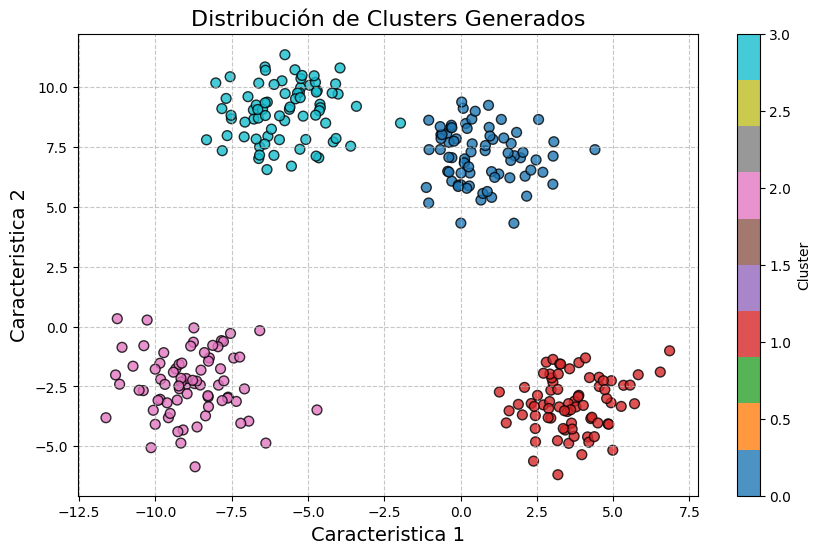

In [4]:
# Dataset para el ejercicio

#datos de prueba
estado = ord('C') # cada grupo debe cambiarlo por su inicial
# generar datos aleatorios y representarlos
X, y = make_blobs(n_samples = 300, centers = 4, random_state = estado, cluster_std = 1.2)

# Crear la figura

plt.figure(figsize=(10,6))

# Gráfico representativo
scatter = plt.scatter(X[: , 0], X[: , 1],
                      c= y, # Coloreamos los puntos en base a los grupos del conjunto y
                      cmap='tab10', # Colores para los grupos de datos
                      s = 50,
                      alpha=0.8,
                      edgecolors="black");

# Personalización
plt.title("Distribución de Clusters Generados", fontsize=16)
plt.xlabel("Caracteristica 1", fontsize=14)
plt.ylabel("Caracteristica 2", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.colorbar(scatter, label="Cluster");

# Mostrar el gráfico
plt.show()


### 🧠 Interpretación

En la anterior ilustración notamos que existen 4 grupos de creados en base al metodo make_blob como datos sinteticos para este ejericicio. Esto podria asumirse que en 300 datos en base a la semilla con la letra "C" genera 4 grupos.

Como siguiente paso vamos a realizar el entrenamiento con el Algoritmo de K-Means.

# 1️⃣ Fase 1: Generación y representación de datos


## 🚀 1.1 Entrenamiento y Predicción de modelo mediante el algoritmo K-Means


In [5]:
# Realizaremos el entrenamiento con K-Means en base a los datos de prueba

# Definimos el número de clusters
numero_clusters = 6

# Entrenamos el modelo
est = KMeans(numero_clusters, n_init=10)
est.fit(X)

# Realizamos una predicción
y_kmeans = est.predict(X)

# Mediante el Silhouette Score para validar si el entremiento realizado tiene sentido
# Importamos la libreria
from sklearn.metrics import silhouette_score

# Ejecutamos la validación del silhouette score
score = silhouette_score(X, y_kmeans)

# Mostramos el resultado
print("Silhouette Score: ", score)


Silhouette Score:  0.5315754957429135


### 🧠 Interpretación

El silhouette Score es una métrica de evaluación de clustering para saber que tan bien está asignado cada punto a su cluster que valida, la distancia de un punto esta tan cerca de su propio cluster y la distancia de un punto esta tan cerca de otro cluster.

La fórmula matemática que se usa es:

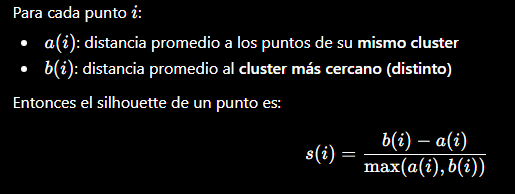



## 🚀 1.2 Previsualizacion y validacion mediante clusters generados

📥 Visualizaremos clusters generados obtenida:

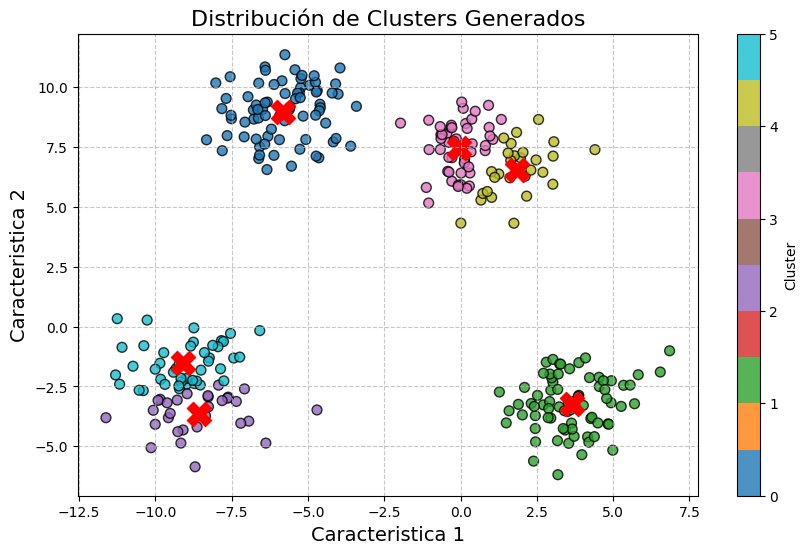

In [6]:
# Crear la figura
plt.figure(figsize=(10,6))

# Gráfico representativo
scatter = plt.scatter(X[: , 0], X[: , 1],
                      c= y_kmeans, # Coloreamos los puntos en base a los grupos del conjunto y_kmeans
                      cmap='tab10', # Colores para los grupos de datos
                      s = 50,
                      alpha=0.8,
                      edgecolors="black");

# Gráficamos el centroide
plt.scatter(
    est.cluster_centers_[:,0], # Coordenada X del centroide
    est.cluster_centers_[:,1], # Coordenada Y del centroide
    marker="X",
    s=300,
    c="red",
    label="Centroides"
)

# Personalización
plt.title("Distribución de Clusters Generados", fontsize=16)
plt.xlabel("Caracteristica 1", fontsize=14)
plt.ylabel("Caracteristica 2", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.colorbar(scatter, label="Cluster");

# Mostrar el gráfico
plt.show()

### 🧠 Interpretación

Para interpretar el valor obtenido con la medición realizada es revisando los limites de la métrica. Esta metrica esta entre [-1,1], donde -1 significa que esta mal asignado, 0 el punto esta mezclado y esta en la frontera, y finalmente, 1 es que esta bien asignado.

El valor obtenido 0.5401656287263469 nos dice que esta en un lugar razonable los puntos obtenidos pero visualizando el gráfico nos dice que hay clusters que podria ser que no deban estar. La métrica nos dice que es algo razonable pero es mejorable. A continuación, realizaremos la optimización del número de clusters.

# 2️⃣ Fase 2: Número óptimo de clusters con técnica del codo

La suma de distancias de un cluster con respecto a su centroide (inercia) se puede calcular con la siguiente función (donde est se corresponde con el modelo anteriormente entrenado).


## 🚀 2.1 Revisamos la Inertia y enlistamos los K posibles desde el 1 al 11

In [8]:
# Obtenemos la inercia del model entrenado

print("Inertia Actual:", est.inertia_) # Inertia que tenemos con el modelo de 6 clusters

# Vamos a revisar el valor con diferente cantidad de clusters

inertias = [] # Lista vacia para almacenar las inercias
K_clusters = range(1,11)

for k in K_clusters:
    est = KMeans(n_clusters=k)
    est.fit(X)
    inertias.append(est.inertia_) # Agregamos la inercia a la lista vacia
    print(f"Cluster {k}: inertia -> {est.inertia_}")# Imprimimos las inertias en base



Inertia Actual: 669.7698683911032
Cluster 1: inertia -> 17244.280320087702
Cluster 2: inertia -> 8442.988673098012
Cluster 3: inertia -> 2527.5139969842608
Cluster 4: inertia -> 833.8027019671172
Cluster 5: inertia -> 771.1115432898005
Cluster 6: inertia -> 673.2392087015463
Cluster 7: inertia -> 623.7692112310186
Cluster 8: inertia -> 531.8697043649559
Cluster 9: inertia -> 480.5989089156215
Cluster 10: inertia -> 421.09933518063013


## 🚀 2.2 Visualización de las inertias encontradas del 1 a 11

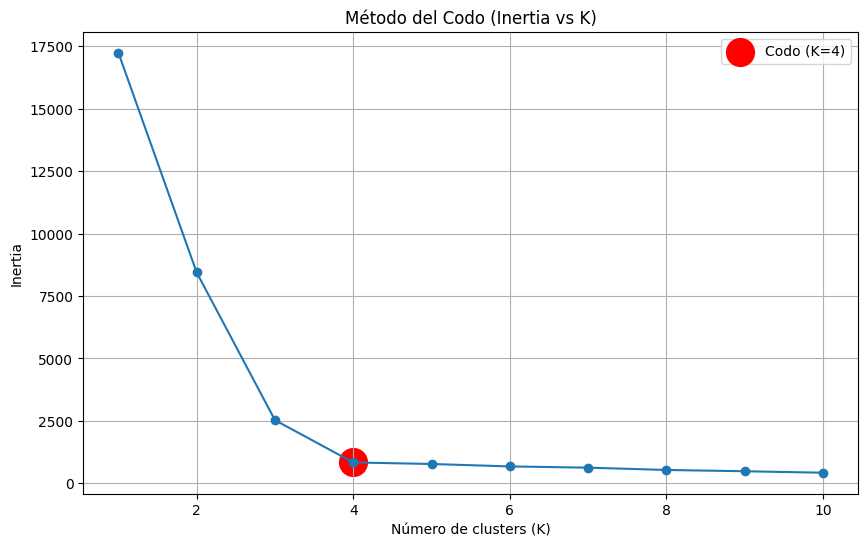

In [13]:
# Graficaremos las inertias que hemos calculado
plt.figure(figsize=(10,6))
plt.plot(K_clusters, inertias, marker='o')

# Identificamos la cantiadad de clusters optimo
k_optimo = 4
plt.scatter(k_optimo, inertias[k_optimo-1], color='red',s=400, label=f"Codo (K={k_optimo})")

# Gráficamos
plt.title("Método del Codo (Inertia vs K)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.legend()
plt.show()

### 🧠 Interpretación

La inercia es una métrica que nos ayuda a saber que tan compacto estan los clusters. Su formula nos dice lo siguiente:
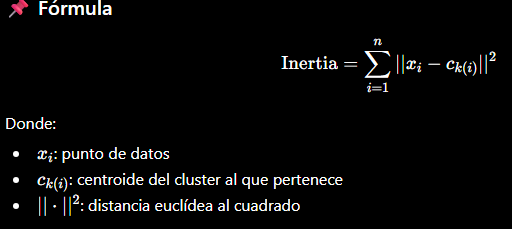

Se obtiene un valor que nos dice que es la sumatoria de los puntos con la diferencia de la posición del centroide elevados al cuadrado. Por ello, realizamos el calculo con el númeroo de clusters de 6 y obtuvimos un valor de 669 pero eso no nos dice nada. Al momento de realizar el calculo con el rango de 1 al 11 y lo gráficamos tuvimos el gráfico de la ilustración.

En el gráfico se muestra el calculo de la inercia desde el 1 al 11 donde el número 4 es el punto donde se rompe la tendencia de bajada y se estabiliza.

Por ello, según el gráfico nos dice que debemos validar el modelo nuevamente con el valor de 4.

## 🚀 2.3 Entrenamos con el número de clusters de 4

In [14]:
# Realizaremos el entrenamiento con K-Means en base a los datos de prueba

# Definimos el número de clusters
numero_clusters = 4

# Entrenamos el modelo
est = KMeans(numero_clusters, n_init=10)
est.fit(X)

# Realizamos una predicción
y_kmeans = est.predict(X)

# Mediante el Silhouette Score para validar si el entremiento realizado tiene sentido
# Importamos la libreria
from sklearn.metrics import silhouette_score

# Ejecutamos la validación del silhouette score
score = silhouette_score(X, y_kmeans)

# Mostramos el resultado
print("Silhouette Score: ", score)


Silhouette Score:  0.7484500077274081


### 🧠 Interpretación

En este caso el silhouette score es de 0.75 que nos dice que ahora es mucho mejor y no esta en la frontera como en el caso anterior.

Por ello, esto demuestra que el número de clusters es optimo para nuestro ejercicio.

## 🚀 2.4 Previsualizacion y validacion mediante K-Means

📥 Visualizaremos la K-Means de 4 obtenida:

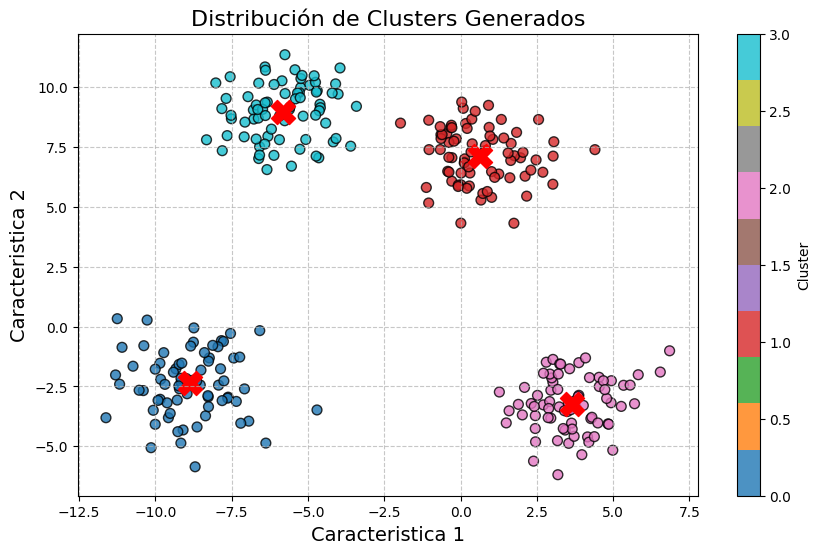

In [15]:
# Crear la figura
plt.figure(figsize=(10,6))

# Gráfico representativo
scatter = plt.scatter(X[: , 0], X[: , 1],
                      c= y_kmeans, # Coloreamos los puntos en base a los grupos del conjunto y_kmeans
                      cmap='tab10', # Colores para los grupos de datos
                      s = 50,
                      alpha=0.8,
                      edgecolors="black");

# Gráficamos el centroide
plt.scatter(
    est.cluster_centers_[:,0], # Coordenada X del centroide
    est.cluster_centers_[:,1], # Coordenada Y del centroide
    marker="X",
    s=300,
    c="red",
    label="Centroides"
)

# Personalización
plt.title("Distribución de Clusters Generados", fontsize=16)
plt.xlabel("Caracteristica 1", fontsize=14)
plt.ylabel("Caracteristica 2", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.colorbar(scatter, label="Cluster");

# Mostrar el gráfico
plt.show()


### 🧠 2.4.1 Interpreta los resultados obtenidos

Revisando el gráfico notamos que existen solamente 4 clusters como se visualizó al principio del ejercicio. Los centroides estan definidos correctamente de acuerdo a los calculos anteriores pero aun queda la duda si con 3 clusters podría mejorar aun más. Segun las métricas de Silhouetes e Inertia tenemos un modelo optimizado y estan agrupados eficientemente los puntos.

### 🧠 2.4.2 Comparativa de los modelos por números de clusters

Como hemos revisado durante esta fase 2 encontramos los siguientes puntos:

- Puntaje de Silhoutte
  En el modelo de K=6 teniamos clusters muy unidos donde las distancias son muy cortas y la metrica nos dice que esta el modelo en un punto razonable. Sin embargo, con el modelo K=4 nos muetra algo más cercano a lo que buscamos donde esta métrica que esta muy cerca del 0.8 que dice que es optimo. Nos queda aun la duda que pasaría si lo ponemos con K=3 sin llegar a tener un sobreentrenamiento e invalidar el modelo.

- Inercia
  En el modelo de K=6 teniamos clusters no tan compactos pero nos decia que estabamos en una frontera de tener clusters que esta mal agrupados, en este númeor no necesariamente estan mal agrupados pero si estan llegando a ese limite. Por otro lado, k=4 estamos justo en el punto de inflexión de clusters donde empieza a estabilizarse la metrica y nos dice que ese es el valor optimo. Cambiandolo mejoró la metrica anterior y se ve más eficiente el modelo.

# 3️⃣ Fase 3: Comparativa con otros modelos

Cada grupo debe elegir un algoritmo de entre los vistos en clase (Clustering Jerárquico[1] o DBSCAN[2]). Se debe utilizar el algoritmo elegido para agrupar los elementos de la fase anterior y comparar los resultados obtenidos entre ambos algoritmos.

Vamos a realizar la comparativa con DBSCAN el cual agrupa puntos que están densamente conectados y marca como ruido los puntos aislado. Este algoritmo a diferencia del K-Means, tenemos clusters de cualquier forma y se basa en densidad para generarlos.

## 🚀 3.1 Generación de datos en base al la inicial del nombre


In [24]:
#Generar datos de ejemplo

estado = ord('C') # cada grupo debe cambiarlo por su inicial
# generar datos aleatorios y representarlos
X, y = make_blobs(n_samples = 300, centers = 4, random_state = estado, cluster_std = 1.2)


## 🚀 3.2 Buscaremos los valores de epsilon y mins

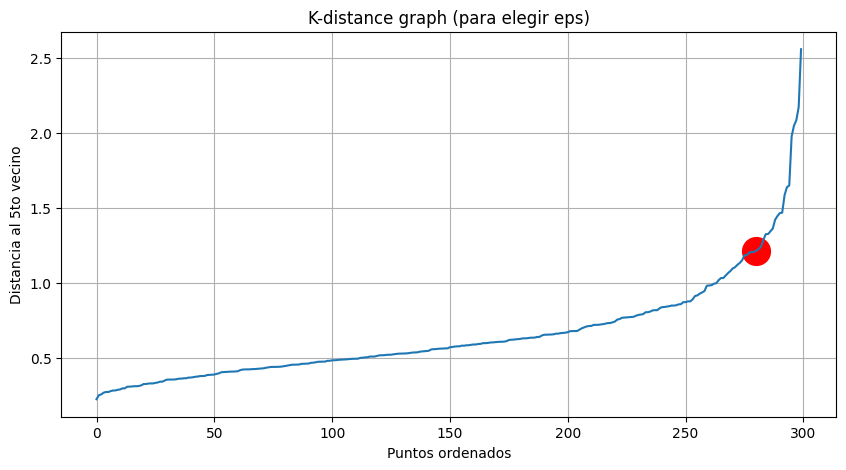

In [46]:
# Importación de libreria
from sklearn.neighbors import NearestNeighbors

# Buscamos el valodr de epsilon
min_samples = 5

# Entrenamiento con el algoritmo de K-NN
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)

# Obtenemos las distancias y los indices
distances, indices = neighbors_fit.kneighbors(X)

# Obtenemos las listas para el gráfico
distances = np.sort(distances[:,min_samples-1])

# Configuramos el gráfico
plt.figure(figsize=(10,5))


# Gráficamos el centroide
eps_point = 280 # Esto representa un 1.2
plt.scatter(eps_point, distances[eps_point], color='red',s=400, label=f"Density Point (={eps_point})")


plt.plot(distances)
plt.title("K-distance graph (para elegir eps)")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al 5to vecino")
plt.grid(True)
plt.show()

## 🚀 3.3 Entrenamiento de modelo mediante DBSCAN

In [47]:
# Importamos la libreria de sklearn de DBSCAN
from sklearn.cluster import DBSCAN

# Crear modelo con un epsilon de 0,5 y min samples de 5
db = DBSCAN(eps=1.2, min_samples=min_samples)
labels = db.fit_predict(X)

## 🚀 3.4 Previsualizacion y validacion mediante DBSCAN
📥 Visualizaremos el modelo de DBSCAN obtenida:

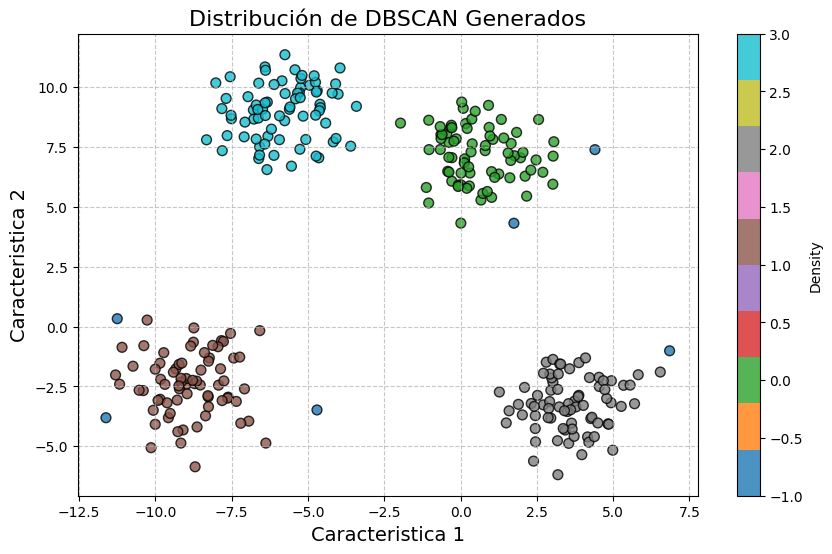

In [34]:
plt.figure(figsize=(10,6))


# Gráfico representativo
scatter = plt.scatter(X[: , 0], X[: , 1],
                      c= labels, # Coloreamos los puntos en base a los grupos del conjunto y
                      cmap='tab10', # Colores para los grupos de datos
                      s = 50,
                      alpha=0.8,
                      edgecolors="black");

# Personalización
plt.title("Distribución de DBSCAN Generados", fontsize=16)
plt.xlabel("Caracteristica 1", fontsize=14)
plt.ylabel("Caracteristica 2", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.colorbar(scatter, label="Density");

# Mostrar el gráfico
plt.show()

### 🧠 Interpretación

Al comparar ambos gráficos, se observa cómo el algoritmo K-Means en la gráfica **"Distribución de Clusters Generados"** agrupa la totalidad de los datos en cuatro conglomerados bien definidos basados en la distancia hacia sus centroides (marcados con una "X" roja), forzando incluso a los puntos más distantes o aislados a formar parte de un clúster. Por el contrario, el algoritmo DBSCAN en la gráfica **"Distribución de DBSCAN Generados"** realiza una agrupación basada puramente en la densidad local de los puntos; esto le permite identificar con precisión las mismas cuatro concentraciones principales, pero con la ventaja clave de detectar y separar automáticamente los puntos periféricos o dispersos como ruido o valores atípicos (*outliers*), los cuales quedan representados con un color azul diferente (valor -1 en la barra lateral) en lugar de ser absorbidos incorrectamente por los grupos principales.

# 🚀 Aplicación en Entorno Laboral
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**



# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
El análisis de datos y las técnicas de Machine Learning permiten identificar patrones relevantes para mejorar la toma de decisiones en entornos reales. En un entorno laboral, estos procesos pueden aplicarse para detectar anomalías, optimizar reportes, automatizar análisis y generar información más precisa para apoyar decisiones estratégicas basadas en datos.